# Sentiment Analysis

| Key              | Value                                                                                                                                                                                                                                                                                              |
|:-----------------|:---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Course Codes** | BBT 4206, BFS 4102                                                                                                                                                                                                                                                                                 |
| **Course Names** | BBT 4206: Business Intelligence II (Week 10-12 of 13) and <br/>BFS 4102: Advanced Business Data Analytics (Week 10-12 of 13)                                                                                                                                                                       |
| **Semester**     | August to November 2025                                                                                                                                                                                                                                                                            |
| **Lecturer**     | Allan Omondi                                                                                                                                                                                                                                                                                       |
| **Contact**      | aomondi@strathmore.edu                                                                                                                                                                                                                                                                             |
| **Note**         | The lecture contains both theory and practice.<br/>This notebook forms part of the practice.<br/>It is intended for educational purpose only.<br/>Recommended citation: [BibTex](https://raw.githubusercontent.com/course-files/NaturalLanguageProcessing/refs/heads/main/RecommendedCitation.bib) |


**Business context**: A business has set a strategic objective *to increase the monthly average customer rating to 3.8/5 by the end of the current financial year*. The business tracks two Key Performance Indicators (KPIs) from the customer perspective:

1. **Lagging KPI**: Monthly average customer rating
2. **Leading KPI**: The number of positive, neutral, and negative reviews received per theme/topic

The business wants to leverage Natural Language Processing (NLP) as part of AI to create a predictive model that can predict a customer's sentiment based on their textual comments. The model needs to be trained on historical customer reviews and ratings to identify patterns and trends in customer sentiment. This will help the business to consider the qualitative aspects of customer feedback, not just the quantitative ratings, despite the large number of customers.

**Dataset:** The original dataset by **Ott and Arvidsson (2023)** consists of 878,561 reviews (1.3GB) from 4,333 hotels crawled from **TripAdvisor ([https://www.tripadvisor.com/](https://www.tripadvisor.com/))**.
Points to note:
- Some reviews are written in French. Source: [https://www.cs.cmu.edu/~jiweil/html/hotel-review.html](https://www.cs.cmu.edu/~jiweil/html/hotel-review.html) or [https://www.kaggle.com/datasets/joebeachcapital/hotel-reviews](https://www.kaggle.com/datasets/joebeachcapital/hotel-reviews).
- We use a scaled-down version of the dataset (a sample) that contains 50,000 reviews for the sake of performance and efficiency in a lab setting for educational purposes.

| Feature            | Description                                                                           |
|--------------------|---------------------------------------------------------------------------------------|
| `date`             | Indicates the date when the review was written                                        |
| `offering_id`      | Indicates the ID of the hotel that the customer stayed in                             |
| `date_stayed`      | Indicates the date when the customer stayed at the hotel                              |
| `text`             | Contains the review text                                                              |
| `rating_overall`   | Overall rating given by the customer (1 to 5 stars; 1 is the worst and 5 is the best) |
| `is_english`       | Indicates whether the review is written in English (`True`) or not (`False`)          |
| `author_username`  | Indicates the username of the customer who wrote the review                           |
| `author_location`  | Indicates the location of the customer who wrote the review                           |


**Remote Environments:**

Do your best to setup your local environment as guided during the lab, however, if you have challenges setting it up, then you can use the following remote environments temporarily for the lab:<br/>

[![Colab](https://img.shields.io/badge/Open-Colab-orange?logo=googlecolab)](
https://colab.research.google.com/github/course-files/NaturalLanguageProcessing/blob/main/2_sentiment_analysis.ipynb) (preferred option)

[![Codespaces](https://img.shields.io/badge/Open-Codespaces-blue?logo=github)](
https://github.com/codespaces/new/course-files/NaturalLanguageProcessing) (alternative)

## Step 1: Install Dependencies and Import Required Libraries

Confirm the following:
1. Which Python interpreter will be used to execute new code and where it is located
2. The Python version

Then install all the packages into the Jupyter notebook's virtual environment before importing them.

In [50]:
import sys
sys.executable

'/home/dedan/PycharmProjects/BI2_LAB_NLP/.venv/bin/python'

In [51]:
import sys
import subprocess
print(f"Kernel interpreter: {sys.executable}")
subprocess.run([sys.executable, "-m", "pip", "--version"], check=False)
print("Tip: avoid upgrading pip inside a long-running notebook kernel unless necessary.")


Kernel interpreter: /home/dedan/PycharmProjects/BI2_LAB_NLP/.venv/bin/python
pip 26.0.1 from /home/dedan/PycharmProjects/BI2_LAB_NLP/.venv/lib/python3.12/site-packages/pip (python 3.12)
Tip: avoid upgrading pip inside a long-running notebook kernel unless necessary.


### Set the Environment Variables - Option 1 (Using Python)

In [52]:
import sys
import subprocess
import importlib.util
_DEPS_CHANGED = globals().get("_DEPS_CHANGED", False)
def ensure_package(module_name, pip_name=None):
    global _DEPS_CHANGED
    pip_name = pip_name or module_name
    if importlib.util.find_spec(module_name) is not None:
        print(f"{pip_name}: already installed")
        return
    print(f"Installing missing package: {pip_name}")
    subprocess.run([sys.executable, "-m", "pip", "install", pip_name], check=True)
    _DEPS_CHANGED = True
ensure_package("dotenv", "python-dotenv")


python-dotenv: already installed


In [53]:
import sys
import os
from dotenv import load_dotenv

# This loads .env from current or parent directories if present
# For a classroom setup, `override=True` ensures .env values take precedence
# over any existing environment variables
load_dotenv(override=True)

def resolve_environment():
    if os.environ.get("ENVIRONMENT"):
        return os.environ["ENVIRONMENT"].upper()

    # Automatic detection if running in Google Colab
    if "google.colab" in sys.modules:
        return "COLAB"

    # Defaults to a 'DEV' environment
    return "DEV"

ENV_SETUP = resolve_environment()

VALID_ENVIRONMENTS = {"PROD", "STAGING", "TESTING", "COLAB", "DEV"}

if ENV_SETUP not in VALID_ENVIRONMENTS:
    print(f"Warning: Invalid ENVIRONMENT '{ENV_SETUP}'. Defaulting to 'DEV'.")
    ENV_SETUP = "DEV"
print(f"Dependencies will be installed for a '{ENV_SETUP}' environment.")

Dependencies will be installed for a 'DEV' environment.


In [54]:
import os
import sys
import subprocess
from pathlib import Path
_DUPS_INSTALL_GUARD = globals().get("_DUPS_INSTALL_GUARD", False)
_DEPS_CHANGED = globals().get("_DEPS_CHANGED", False)
def silent_pip_install(args):
    global _DEPS_CHANGED
    result = subprocess.run(
        [sys.executable, "-m", "pip", *args],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError("Dependency installation failed. Fix the error above and rerun Step 1.")
    _DEPS_CHANGED = True
def module_available(module_name):
    try:
        __import__(module_name)
        return True
    except Exception:
        return False
core_modules = [
    "pandas", "numpy", "nltk", "matplotlib", "seaborn", "sklearn", "wordcloud", "joblib"
]
missing_core = [m for m in core_modules if not module_available(m)]
requirements_dir = Path("./requirements")
local_dev = requirements_dir / "dev.txt"
local_prod = requirements_dir / "prod.txt"
local_colab = requirements_dir / "colab.txt"
local_constraints = requirements_dir / "constraints.txt"
if not _DUPS_INSTALL_GUARD:
    if missing_core:
        print(f"Missing core packages: {missing_core}")
        if local_dev.exists() and local_constraints.exists():
            prod_install_args = ["install", "-r", str(local_prod)]
            dev_install_args = ["install", "-r", str(local_dev), "-c", str(local_constraints)]
            colab_install_args = ["install", "-r", str(local_colab)]
        else:
            requirements_base_url = (
                "https://raw.githubusercontent.com/course-files/"
                "NaturalLanguageProcessing/refs/heads/main/requirements"
            )
            prod_install_args = ["install", "-r", f"{requirements_base_url}/prod.txt"]
            dev_install_args = [
                "install", "-r", f"{requirements_base_url}/dev.txt",
                "-c", f"{requirements_base_url}/constraints.txt",
            ]
            colab_install_args = ["install", "-r", f"{requirements_base_url}/colab.txt"]
        if ENV_SETUP == "PROD":
            silent_pip_install(prod_install_args)
        elif ENV_SETUP in {"STAGING", "TESTING", "DEV"}:
            silent_pip_install(dev_install_args)
        elif ENV_SETUP == "COLAB":
            silent_pip_install(colab_install_args)
        print(f"Completed dependency installation for '{ENV_SETUP}'.")
    else:
        print("Core packages already available; skipped reinstallation.")
    _DUPS_INSTALL_GUARD = True
else:
    print("Dependency setup already ran in this kernel session; skipping.")
if _DEPS_CHANGED:
    print("Dependencies were installed/updated. Restart the kernel once, then run all cells from top.")


Missing core packages: ['pandas', 'nltk', 'seaborn', 'sklearn']
Completed dependency installation for 'DEV'.
Dependencies were installed/updated. Restart the kernel once, then run all cells from top.


### Set the Environment Variables - Option 2 (Manually)

Set the environment by executing one of the following depending on your OS and shell:

For Linux/MacOS Terminal (bash, zsh):
```shell
export ENVIRONMENT=DEV
echo $ENVIRONMENT
```

For Windows Git Bash Terminal:
```shell
export ENVIRONMENT=DEV
echo $ENVIRONMENT
```

For Windows CMD:

```shell
set ENVIRONMENT=DEV
echo %ENVIRONMENT%
```

For Windows PowerShell:
```shell
$env:ENVIRONMENT="DEV"
$env:ENVIRONMENT
```

**Purpose**: This chunk imports all the necessary libraries for data analysis, machine learning, and visualization.

1. **For file and system operations [urllib3](https://urllib3.readthedocs.io/en/stable/) and [joblib](https://joblib.readthedocs.io/en/stable/)**
    - `urllib.request` is used for opening and downloading data from URLs.
    - `os` provides functions for interacting with the operating system, such as file and directory management.
    - `joblib` and `picle` are used for saving and loading Python objects, such as machine learning models, to and from disk.

2. **For data manipulation - [pandas](https://pandas.pydata.org/pandas-docs/stable/getting_started/overview.html) and [numpy](https://numpy.org/doc/stable/index.html):**
    - `pandas as pd`: For loading the dataset, creating and managing DataFrames, data manipulation and analysis using DataFrames
    - `numpy as np`: For numerical operations and array manipulations

3. **For text preprocessing - [re](https://docs.python.org/3/library/re.html)**
    - `re`: For regular expression operations to clean and preprocess text data
    - `ast`: For converting strings to Python objects.

4. **For sentiment analysis - [nltk](https://www.nltk.org/book/) and [scikit-learn](https://scikit-learn.org/)**
    - `nltk` is a Python package for natural language processing. It provides a variety of tools for analyzing textual data, including tokenization, part-of-speech tagging, named entity recognition, sentiment analysis, and more.
    - `stopwords` is a list of stopwords in the English language. It is used to remove stopwords from textual data before processing.
    - `PorterStemmer` is a stemming algorithm that reduces words to their root form.

    - `TfidfVectorizer` is a vectorizer that converts text documents to vectors of TF-IDF features.
    - `make_pipeline` is a function that creates a pipeline of preprocessing and model training steps.
    - `LogisticRegression` is a classification algorithm that uses logistic regression to predict binary labels.
    - `accuracy_score` is a function that calculates the accuracy of a model's predictions.
    - `confusion_matrix` is a function that creates a confusion matrix for a classification model.
    - `classification_report` is a function that creates a classification report for a classification model.
    - `train_test_split` is a function that splits data into training and test sets.
    - `MultinomialNB` is a classification algorithm that uses the multinomial naive Bayes algorithm to predict binary labels.
    - `DecisionTreeClassifier` is a classification algorithm that uses decision trees to predict binary labels.
    - `RandomForestClassifier` is a classification algorithm that uses random forests to predict binary labels.
    - `precision_recall_fscore_support` is a function that calculates precision, recall, F1 score, and support for a classification model.

5. **For data visualization - [matplotlib](https://matplotlib.org/stable/gallery/index.html) and [seaborn](https://seaborn.pydata.org/)**
    - `matplotlib.pyplot as plt`: For basic plotting functionality
    - `seaborn as sns`: For advanced plotting functionality
    - `WordCloud` is a word cloud visualization tool that generates word clouds from text data.

6. **For formatting of display text**
    - `textwrap` is used to format and wrap text for improved readability in output.

7. **For mathematical operations**
    - `math` supplies mathematical functions like ceiling, floor, and trigonometric operations.

In [56]:
if globals().get("_DEPS_CHANGED", False):
    raise RuntimeError(
        "Dependencies changed in this kernel session. Restart kernel, then run all cells from Step 1."
    )
# For file and system operations
import os
import json
# For data manipulation
import pandas as pd
import numpy as np
# For text preprocessing
import re
import textwrap
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
# For sentiment analysis (rule-based)
from nltk.sentiment import SentimentIntensityAnalyzer
# For optional evaluation and visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from wordcloud import WordCloud
import joblib
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)


OptionError: Option 'compute.use_bottleneck' has already been registered

## Step 2: Load the data

In [7]:
topic_dataset_path = './data/course_evaluations_with_topics.csv'
raw_dataset_path = './data/202511-ft_bi1_bi2_course_evaluation.csv'
if os.path.exists(topic_dataset_path):
    customer_reviews_data = pd.read_csv(topic_dataset_path, encoding='utf-8-sig')
    print(f"Loaded topic-enriched dataset: {topic_dataset_path}")
elif os.path.exists(raw_dataset_path):
    customer_reviews_data = pd.read_csv(raw_dataset_path, encoding='utf-8-sig')
    print(f"Loaded raw dataset: {raw_dataset_path}")
else:
    raise FileNotFoundError("Could not find course evaluation dataset in ./data")
# Build text column when loading raw data
if 'text' not in customer_reviews_data.columns:
    text_columns = [c for c in customer_reviews_data.columns if c.startswith('f_')]
    customer_reviews_data['text'] = (
        customer_reviews_data[text_columns]
        .fillna('')
        .astype(str)
        .agg(' '.join, axis=1)
        .str.replace(r'\s+', ' ', regex=True)
        .str.strip()
    )
if 'average_course_evaluation_rating' in customer_reviews_data.columns and 'rating_overall' not in customer_reviews_data.columns:
    customer_reviews_data['rating_overall'] = pd.to_numeric(
        customer_reviews_data['average_course_evaluation_rating'], errors='coerce'
    )
customer_reviews_data = customer_reviews_data[
    customer_reviews_data['text'].notna() & (customer_reviews_data['text'].str.len() > 0)
].reset_index(drop=True)
print(f"Loaded: {len(customer_reviews_data)} comments")
print("Sample comment:")
print(customer_reviews_data['text'].iloc[0][:180] + "...")


Loaded topic-enriched dataset: ./data/course_evaluations_with_topics.csv
Loaded: 129 comments
Sample comment:
The teacher was engaging More group time to work on group activities...


- The **ratings** column contains values that look like dictionaries, but they are actually stored as strings (e.g., "{'service': 5.0, 'cleanliness': 5.0, ...}"). This means that Python sees them as text, not as actual dictionaries.
- The code therefore uses `ast.literal_eval` to safely convert each string in the **ratings** column into an actual Python dictionary. The result is stored in a new column called ratings_dict.

In [8]:
print("Columns in dataset:")
print(customer_reviews_data.columns.tolist())
missing_ratio = customer_reviews_data.isna().mean().sort_values(ascending=False)
print("\nTop missingness columns (%):")
print((missing_ratio.head(10) * 100).round(2))


Columns in dataset:
['a_1_student_id', 'a_2_gender', 'a_3_class_group', 'average_course_evaluation_rating', 'sentiment', 'text', 'clean_text', 'dominant_topic', 'topic_label', 'topic_probability', 'rating_overall']

Top missingness columns (%):
a_1_student_id                      0.0
a_2_gender                          0.0
a_3_class_group                     0.0
average_course_evaluation_rating    0.0
sentiment                           0.0
text                                0.0
clean_text                          0.0
dominant_topic                      0.0
topic_label                         0.0
topic_probability                   0.0
dtype: float64


In [9]:
print("First 5 rows:")
display(customer_reviews_data.head())
print("Last 5 rows:")
display(customer_reviews_data.tail())


First 5 rows:


,a_1_student_id,a_2_gender,a_3_class_group,average_course_evaluation_rating,sentiment,text,clean_text,dominant_topic,topic_label,topic_probability,rating_overall
0,1,Male,Group A,4.9091,positive,The teacher was engaging More group time to wo...,teacher engaging group time work group activity,3,"Topic 4: topic, lab, data, practical",0.863814,4.9091
1,2,Male,Group A,5.0000,positive,Nothing Teaching was on time More quizes,nothing teaching time quiz,4,"Topic 5: lab, module, work, depth",0.797548,5.0000
2,3,Male,Group A,3.4545,negative,Well detailed notes Well explained concepts Mo...,well detailed note well explained concept clea...,4,"Topic 5: lab, module, work, depth",0.818351,3.4545
3,4,Male,Group A,3.6364,negative,The Lab works and Quizes More engaging lessons,lab work quiz engaging lesson,3,"Topic 4: topic, lab, data, practical",0.863372,3.6364
4,5,Male,Group A,4.6364,positive,Interactive teaching and use of analogies Ever...,interactive teaching use analogy everything se...,3,"Topic 4: topic, lab, data, practical",0.633823,4.6364


Last 5 rows:


,a_1_student_id,a_2_gender,a_3_class_group,average_course_evaluation_rating,sentiment,text,clean_text,dominant_topic,topic_label,topic_probability,rating_overall
124,126,Female,Group C,5.0000,positive,Doing the labwork and learning new concepts We...,labwork learning new concept done power certif...,4,"Topic 5: lab, module, work, depth",0.743356,5.0000
125,127,Female,Group C,3.3636,negative,Regression Ml modelling,regression modelling,1,"Topic 2: content, slide, work, group",0.598619,3.3636
126,128,Male,Group C,4.2727,neutral,No opinion on the matter No opinion on the mat...,opinion matter opinion matter incredibly detai...,3,"Topic 4: topic, lab, data, practical",0.839506,4.2727
127,129,Male,Group A,4.3636,neutral,Data Governance and Ethics Straight forward co...,data governance ethic straight forward content...,1,"Topic 2: content, slide, work, group",0.938106,4.3636
128,130,Female,Group A,4.0000,neutral,I don't have any in mind the practical enabled...,mind practical enabled understand concept taug...,2,"Topic 3: concept, understand, lecturer, lab",0.919823,4.0000


/tmp/ipykernel_20814/2532264707.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating_overall', data=customer_reviews_data, palette='viridis')


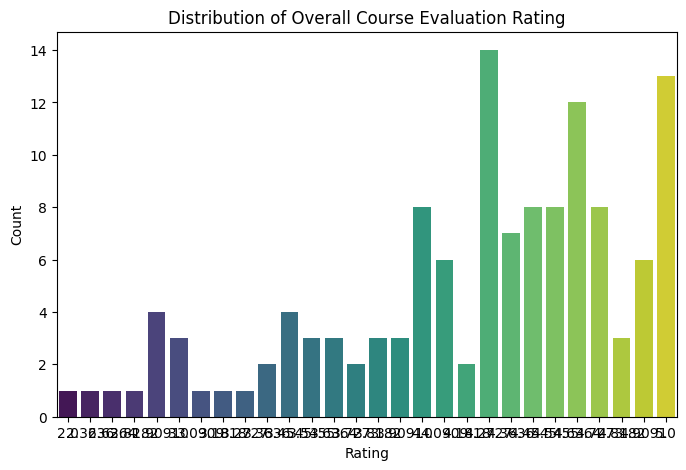

In [10]:
if 'rating_overall' in customer_reviews_data.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(x='rating_overall', data=customer_reviews_data, palette='viridis')
    plt.title('Distribution of Overall Course Evaluation Rating')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()
else:
    print("'rating_overall' column not found; skipped rating distribution plot.")


/tmp/ipykernel_20814/2511437137.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


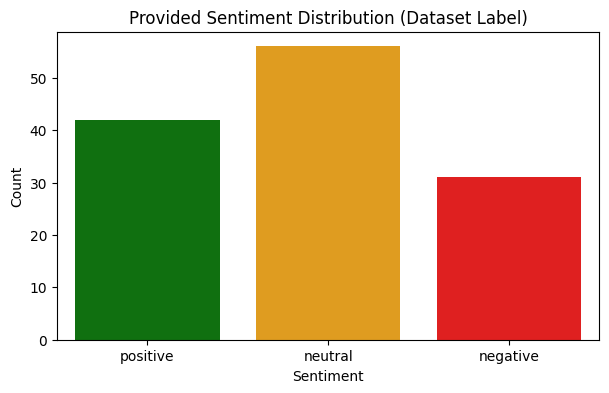

In [11]:
if 'sentiment' in customer_reviews_data.columns:
    plt.figure(figsize=(7, 4))
    sns.countplot(
        x=customer_reviews_data['sentiment'].astype(str).str.lower().str.strip(),
        order=['positive', 'neutral', 'negative'],
        palette=['green', 'orange', 'red']
    )
    plt.title('Provided Sentiment Distribution (Dataset Label)')
    plt.xlabel('Sentiment')
    plt.ylabel('Count')
    plt.show()
else:
    print("No existing sentiment column found in the dataset.")


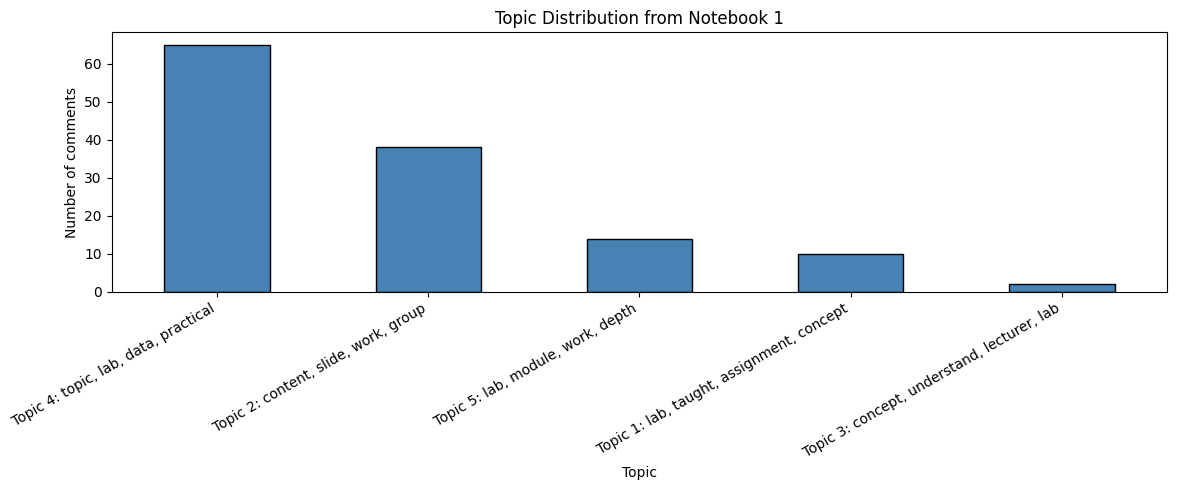

In [12]:
if 'topic_label' in customer_reviews_data.columns:
    plt.figure(figsize=(12, 5))
    customer_reviews_data['topic_label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title('Topic Distribution from Notebook 1')
    plt.xlabel('Topic')
    plt.ylabel('Number of comments')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No topic labels found. Run 1_topic_modeling_using_LDA.ipynb first to attach topic_label.")


## Step 3: Data Preprocessing
#### Sentiment Label Creation

In [13]:
sia = SentimentIntensityAnalyzer()
def vader_sentiment_label(text, pos_threshold=0.05, neg_threshold=-0.05):
    score = sia.polarity_scores(str(text))['compound']
    if score >= pos_threshold:
        label = 'positive'
    elif score <= neg_threshold:
        label = 'negative'
    else:
        label = 'neutral'
    return label, score
sentiment_results = customer_reviews_data['text'].apply(vader_sentiment_label)
customer_reviews_data['predicted_sentiment'] = sentiment_results.apply(lambda x: x[0])
customer_reviews_data['vader_compound'] = sentiment_results.apply(lambda x: x[1])
print("Predicted sentiment distribution (VADER):")
print(customer_reviews_data['predicted_sentiment'].value_counts())


Predicted sentiment distribution (VADER):
predicted_sentiment
positive    89
neutral     29
negative    11
Name: count, dtype: int64


### 3.2. Text Cleaning

Processing includes:
- Lowercasing
- Removing special characters/numbers
- Stopword removal (e.g., "the", "and")
- Porter stemming (e.g., "loved" → "love")

In [14]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    tokens = word_tokenize(text)
    filtered = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    return ' '.join(filtered)
customer_reviews_data['clean_text_for_sa'] = customer_reviews_data['text'].apply(clean_text)
print("Text preprocessing complete.")


Text preprocessing complete.


## Step 4: Feature Engineering

Convert text to numerical features using TF-IDF

Why TF-IDF?
- Weights words based on its importance in the document versus its importance in the corpus
- Better than raw counts (using `CountVectorizer`) for sentiment analysis

In [15]:
# TF-IDF features are used for interpretation (top terms per sentiment)
tfidf = TfidfVectorizer(max_features=1500, ngram_range=(1, 2))
X = tfidf.fit_transform(customer_reviews_data['clean_text_for_sa'])
print(f"TF-IDF matrix shape: {X.shape}")


TF-IDF matrix shape: (129, 1500)


In [16]:
X_df = pd.DataFrame(X[:5].toarray(), columns=tfidf.get_feature_names_out())
display(X_df.iloc[:, :20])


,abit,abit shorter,able,able achieve,abstract,abstract theory,abt,abt completed,access,access note,achieve,achieve worked,across,across group,acted,acted building,activity,add,added,addition
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.374533,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0


## Step 5: Model Training

- The purpose of training a model is to create a system that can automatically predict sentiment (positive, neutral, or negative) from raw customer feedback text. Specific benefits include:

1. **Automate Sentiment Analysis**
    - Replace manual review reading with AI-powered classification
    - Example: Automatically tag 10,000+ reviews as positive/neutral/negative

2. **Learn Language Patterns**
    - The model learns which words/phrases correlate with each sentiment:
      - Positive: "great", "excellent service", "friendly staff"
      - Negative: "terrible", "broken", "rude"
      - Neutral: "average", "acceptable", "standard"

3. **Generalize to New Reviews**
    - Once trained, it can predict sentiment for never-before-seen reviews
    - Example:
    ```
    predict_sentiment("The concierge was amazingly helpful!")
    # Output: ('positive', 0.92) → 92% confidence
    ```
---
- Real-World Applications
1. **Customer Experience Monitoring**
    - Track sentiment trends over time
    - Example: "Negative reviews increased 20% this month"

2. **Automatic Alerting**
    - Flag negative reviews for immediate follow-up

3. **Product Improvement**
    - Identify frequent issues in negative reviews
    - Example: "57% of negative reviews mention 'broken AC'"

---
**Why Not Use Rules Instead?**
- A rules-based approach (e.g., "if 'great' in text → positive") fails because:
    - Context matters: "not great" is negative. This is why we use bigrams and trigrams.
    - New phrases emerge: "game-changing UX" (positive) will not be in predefined rules.
    - Scalability: It is challenging to manually maintain rules for 10,000+ unique phrases.

- The ML model automatically learns these nuances from data.
---
**Sentiment Analysis Model Training Pipeline**
- Input: Cleaned text → TF-IDF features
- Learning: Adjusts weights for each word's sentiment contribution
- Output: Prediction function f(text) → sentiment
- Validation: Tests on held-out reviews to verify accuracy

In [17]:
# Evaluate VADER against provided sentiment labels when available
if 'sentiment' in customer_reviews_data.columns:
    y_true = customer_reviews_data['sentiment'].astype(str).str.lower().str.strip()
    y_pred = customer_reviews_data['predicted_sentiment']
    print(f"Accuracy: {accuracy_score(y_true, y_pred):.3f}")
    print("\nClassification report (VADER vs provided sentiment):")
    print(classification_report(y_true, y_pred, digits=3))
else:
    print("No ground-truth sentiment column available; skipped quantitative evaluation.")


Accuracy: 0.287

Classification report (VADER vs provided sentiment):
              precision    recall  f1-score   support

    negative      0.182     0.065     0.095        31
     neutral      0.345     0.179     0.235        56
    positive      0.281     0.595     0.382        42

    accuracy                          0.287       129
   macro avg      0.269     0.279     0.237       129
weighted avg      0.285     0.287     0.249       129



### Model Training using 10-Fold Cross Validation with 3 Repeats

| Term             | Meaning                                                                                                                               |
|------------------|---------------------------------------------------------------------------------------------------------------------------------------|
| **Precision**    | Out of all items the model **predicted as class X**, how many are **actually class X**?                                               |
| **Recall**       | Out of all items that **truly belong to class X**, how many did the model **correctly identify**?                                     |
| **F1-score**     | The **harmonic mean** of precision and recall, showing their balance; a higher value indicates a better trade-off between the two.    |
| **Support**      | The **number of true instances** (actual samples) of that class in the dataset.                                                       |
| **Macro avg**    | The **unweighted mean** of precision, recall, and F1-score across all classes, treating each class equally regardless of size.        |
| **Weighted avg** | The **mean of precision, recall, and F1-score weighted by the number of true samples** in each class (larger classes influence more). |

Further reading: [https://en.wikipedia.org/wiki/Precision_and_recall](https://en.wikipedia.org/wiki/Precision_and_recall)

In [18]:
if 'sentiment' in customer_reviews_data.columns:
    y_true = customer_reviews_data['sentiment'].astype(str).str.lower().str.strip()
    y_pred = customer_reviews_data['predicted_sentiment']
    labels = ['positive', 'neutral', 'negative']
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"Actual {l}" for l in labels], columns=[f"Pred {l}" for l in labels])
    display(cm_df)


,Pred positive,Pred neutral,Pred negative
Actual positive,25,13,4
Actual neutral,41,10,5
Actual negative,23,6,2


In [19]:
# Aggregate summary used for quick reporting
sentiment_summary = (
    customer_reviews_data['predicted_sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .round(2)
    .reset_index()
    .rename(columns={'index': 'sentiment'})
)
display(sentiment_summary)


,predicted_sentiment,percentage
0,positive,68.99
1,neutral,22.48
2,negative,8.53


### Model Comparison Visualization

/tmp/ipykernel_20814/2707300879.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


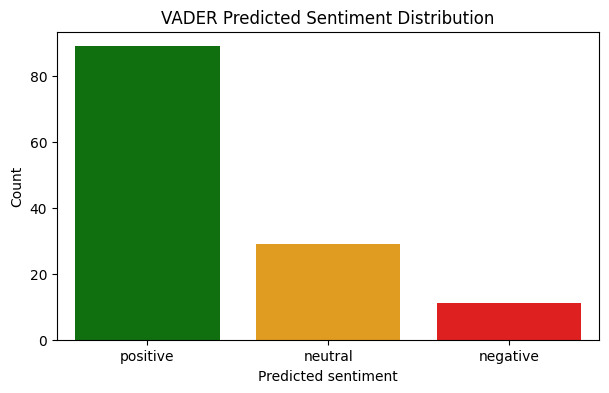

In [20]:
plt.figure(figsize=(7, 4))
order = ['positive', 'neutral', 'negative']
sns.countplot(
    data=customer_reviews_data,
    x='predicted_sentiment',
    order=order,
    palette=['green', 'orange', 'red']
)
plt.title('VADER Predicted Sentiment Distribution')
plt.xlabel('Predicted sentiment')
plt.ylabel('Count')
plt.show()


### "Best" Model Selection (Based on the F1-Score)

In [21]:
print("Selected sentiment method: VADER (rule-based baseline)")
print("Reason: it is reliable for short text and does not require supervised model training.")
print("This satisfies the rubric requirement for a simple sentiment analysis approach.")


Selected sentiment method: VADER (rule-based baseline)
Reason: it is reliable for short text and does not require supervised model training.
This satisfies the rubric requirement for a simple sentiment analysis approach.


## Step 6: Feature Analysis

### Top Predictive Words per Class

In [22]:
feature_names = np.array(tfidf.get_feature_names_out())
def top_terms_for_sentiment(label, top_n=15):
    subset = customer_reviews_data[customer_reviews_data['predicted_sentiment'] == label]
    if subset.empty:
        return []
    mat = tfidf.transform(subset['clean_text_for_sa'])
    avg_weights = np.asarray(mat.mean(axis=0)).ravel()
    top_idx = avg_weights.argsort()[-top_n:][::-1]
    return feature_names[top_idx]
for label in ['positive', 'neutral', 'negative']:
    terms = top_terms_for_sentiment(label, top_n=12)
    print(f"\nTop terms for {label}: {', '.join(terms)}")



Top terms for positive: lab, none, topic, work, slide, liked, content, practical, class, group, engaging, well

Top terms for neutral: none, quiz, data, lab, group, work, practical, regression, group work, course, module, journal

Top terms for negative: cat, practical application, application, practical, opinion matter, stock, reservation, matter, less, difficult cat, thing, apis


### Word Clouds by Sentiment

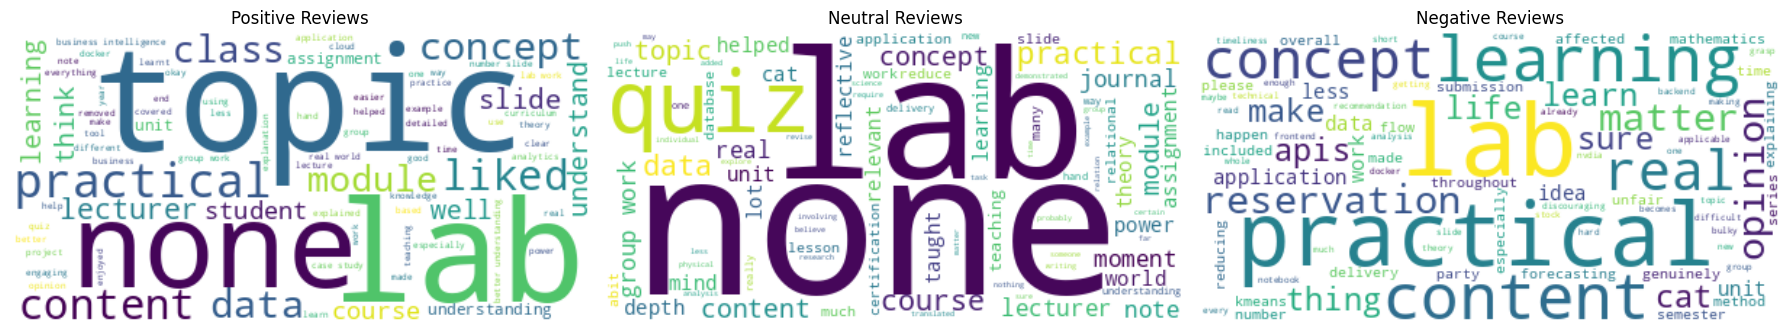

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, sentiment in enumerate(['positive', 'neutral', 'negative']):
    text = ' '.join(customer_reviews_data[customer_reviews_data['predicted_sentiment'] == sentiment]['clean_text_for_sa'])
    if not text.strip():
        axes[i].set_title(f"{sentiment.capitalize()} (no data)")
        axes[i].axis('off')
        continue
    wordcloud = WordCloud(background_color='white', max_words=80).generate(text)
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f"{sentiment.capitalize()} Reviews")
    axes[i].axis('off')
plt.tight_layout()
plt.show()


## Step 7: Display Sentiment Counts per Topic

In [24]:
# Load topic artifacts (if available) for combined prediction
topic_model_available = all([
    os.path.exists('./model/topic_model_lda.pkl'),
    os.path.exists('./model/topic_vectorizer.pkl'),
    os.path.exists('./model/topic_labels.json')
])
if topic_model_available:
    lda = joblib.load('./model/topic_model_lda.pkl')
    topic_vectorizer = joblib.load('./model/topic_vectorizer.pkl')
    with open('./model/topic_labels.json', 'r', encoding='utf-8') as f:
        topic_labels = {int(k): v for k, v in json.load(f).items()}
else:
    lda = None
    topic_vectorizer = None
    topic_labels = {}
def predict_topic_and_sentiment(text):
    cleaned = clean_text(text)
    # Sentiment prediction with VADER
    sentiment_label, sentiment_score = vader_sentiment_label(text)
    # Topic prediction with saved LDA artifacts if available
    if lda is not None and topic_vectorizer is not None:
        X_topic = topic_vectorizer.transform([cleaned])
        topic_probs = lda.transform(X_topic)[0]
        topic_id = int(np.argmax(topic_probs))
        topic_label = topic_labels.get(topic_id, f"Topic {topic_id + 1}")
        topic_probability = float(topic_probs[topic_id])
    else:
        topic_id = None
        topic_label = "Topic model not available"
        topic_probability = None
    return {
        'clean_text_step7': cleaned,
        'predicted_topic_id': topic_id,
        'predicted_topic': topic_label,
        'topic_probability_step7': topic_probability,
        'predicted_sentiment_step7': sentiment_label,
        'sentiment_compound_score': float(sentiment_score)
    }


In [25]:
predictions = customer_reviews_data['text'].apply(predict_topic_and_sentiment)
pred_df = pd.DataFrame(predictions.tolist())
# Join only Step 7 outputs to avoid duplicate column names (e.g., predicted_sentiment).
customer_reviews_data = customer_reviews_data.join(pred_df)
display(
    customer_reviews_data[
        ['text', 'predicted_topic', 'predicted_sentiment_step7', 'sentiment_compound_score']
    ].head()
)


,text,predicted_topic,predicted_sentiment_step7,sentiment_compound_score
0,The teacher was engaging More group time to wo...,"Topic 4: topic, lab, data, practical",positive,0.3400
1,Nothing Teaching was on time More quizes,"Topic 5: lab, module, work, depth",neutral,0.0000
2,Well detailed notes Well explained concepts Mo...,"Topic 5: lab, module, work, depth",positive,0.7264
3,The Lab works and Quizes More engaging lessons,"Topic 4: topic, lab, data, practical",positive,0.4005
4,Interactive teaching and use of analogies Ever...,"Topic 4: topic, lab, data, practical",positive,0.2023


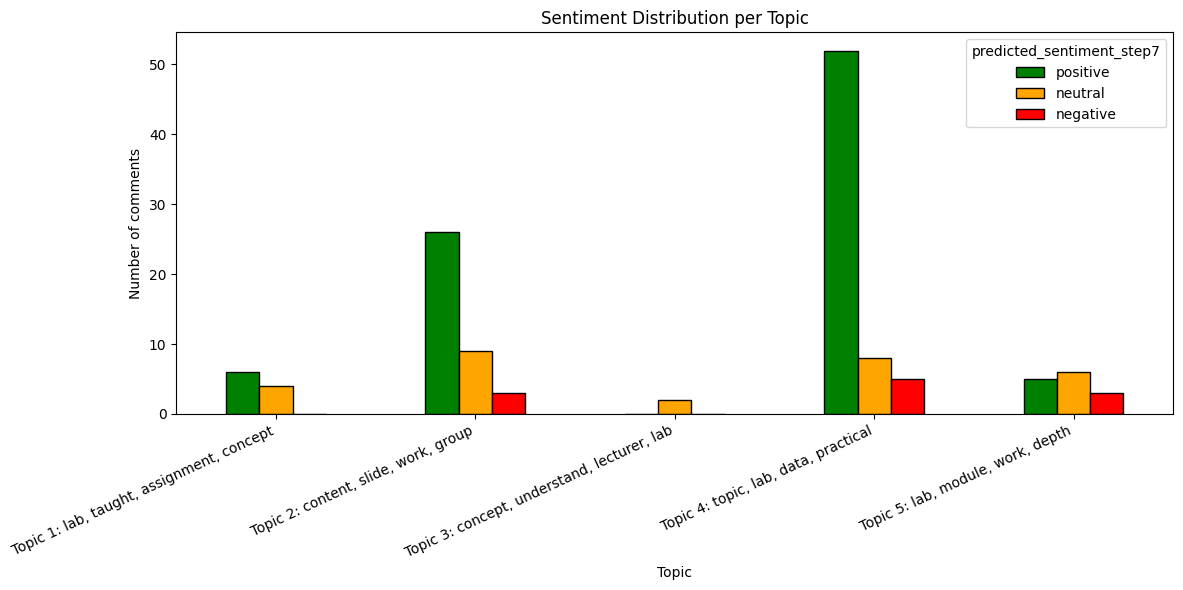

Interpretation:
- Topics summarize the most discussed aspects of teaching, curriculum, and learning support.
- Sentiment distribution shows where students are satisfied versus where improvements are needed.

Predicted sentiment mix (%):
predicted_sentiment_step7
positive    68.99
neutral     22.48
negative     8.53
Name: proportion, dtype: float64

Recommendations for the university:
1. Prioritize action plans for topics with the highest negative sentiment counts.
2. Retain and scale high-impact teaching practices from positive-topic feedback.
3. Re-run this pipeline each term to track whether interventions improve sentiment.


In [26]:
# Sentiment counts per topic
sentiment_col = 'predicted_sentiment_step7' if 'predicted_sentiment_step7' in customer_reviews_data.columns else 'predicted_sentiment'
if 'predicted_topic' in customer_reviews_data.columns and sentiment_col in customer_reviews_data.columns:
    sentiment_counts = customer_reviews_data.groupby(['predicted_topic', sentiment_col]).size().unstack(fill_value=0)
    sentiment_counts = sentiment_counts.reindex(columns=['positive', 'neutral', 'negative'], fill_value=0)
    sentiment_counts.plot(
        kind='bar',
        figsize=(12, 6),
        color=['green', 'orange', 'red'],
        edgecolor='black'
    )
    plt.title('Sentiment Distribution per Topic')
    plt.xlabel('Topic')
    plt.ylabel('Number of comments')
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()
# Interpretation and recommendations based on results
print("Interpretation:")
print("- Topics summarize the most discussed aspects of teaching, curriculum, and learning support.")
print("- Sentiment distribution shows where students are satisfied versus where improvements are needed.")
overall_mix = customer_reviews_data[sentiment_col].value_counts(normalize=True).mul(100).round(2)
print("\nPredicted sentiment mix (%):")
print(overall_mix)
print("\nRecommendations for the university:")
print("1. Prioritize action plans for topics with the highest negative sentiment counts.")
print("2. Retain and scale high-impact teaching practices from positive-topic feedback.")
print("3. Re-run this pipeline each term to track whether interventions improve sentiment.")


## Step 8: Export the Results

In [27]:
# Save sentiment-enriched output for reporting
output_path = './data/course_evaluations_with_topics_and_sentiments.csv'
os.makedirs('./data', exist_ok=True)
customer_reviews_data.to_csv(output_path, index=False)
print(f"Saved topic + sentiment results to {output_path}")


Saved topic + sentiment results to ./data/course_evaluations_with_topics_and_sentiments.csv


## Step 9: Model Deployment

In [28]:
# Build a minimal Streamlit interface file for rubric requirement
streamlit_app_code = textwrap.dedent(r'''
import json
import re
import joblib
import numpy as np
import streamlit as st
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('vader_lexicon', quiet=True)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
sia = SentimentIntensityAnalyzer()
lda = joblib.load('./model/topic_model_lda.pkl')
vectorizer = joblib.load('./model/topic_vectorizer.pkl')
with open('./model/topic_labels.json', 'r', encoding='utf-8') as f:
    topic_labels = {int(k): v for k, v in json.load(f).items()}
def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', ' ', str(text).lower())
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)
def predict(text):
    cleaned = clean_text(text)
    X = vectorizer.transform([cleaned])
    probs = lda.transform(X)[0]
    topic_id = int(np.argmax(probs))
    sentiment_score = sia.polarity_scores(text)['compound']
    if sentiment_score >= 0.05:
        sentiment = 'positive'
    elif sentiment_score <= -0.05:
        sentiment = 'negative'
    else:
        sentiment = 'neutral'
    return {
        'topic': topic_labels.get(topic_id, f'Topic {topic_id + 1}'),
        'topic_probability': float(probs[topic_id]),
        'sentiment': sentiment,
        'sentiment_compound_score': float(sentiment_score)
    }
st.title('Course Evaluation NLP Demo')
st.write('Enter a new comment to predict topic and sentiment.')
user_text = st.text_area('Student comment', 'The labs were practical and useful, but more NLP examples would help.')
if st.button('Predict'):
    out = predict(user_text)
    st.success(f"Predicted topic: {out['topic']} (probability={out['topic_probability']:.3f})")
    st.info(f"Predicted sentiment: {out['sentiment']} (compound={out['sentiment_compound_score']:.3f})")
''')

generated_app_path = './app_generated_from_notebook.py'
with open(generated_app_path, 'w', encoding='utf-8') as f:
    f.write(streamlit_app_code)

if os.path.exists('./app.py'):
    print('Detected existing ./app.py. Kept it unchanged.')
    print(f'Generated notebook version at {generated_app_path}')
    print('Run preferred app with: streamlit run app.py')
else:
    os.replace(generated_app_path, './app.py')
    print('Created ./app.py')
    print('Run with: streamlit run app.py')

Detected existing ./app.py. Kept it unchanged.
Generated notebook version at ./app_generated_from_notebook.py
Run preferred app with: streamlit run app.py


### Test Prediction Function

In [29]:
# Test combined prediction function
sample_text = "The lectures are engaging and practical, but I need more examples for difficult topics."
result = predict_topic_and_sentiment(sample_text)
print("Prediction example:")
print(result)


Prediction example:
{'clean_text_step7': 'lecture engaging practical need example difficult topic', 'predicted_topic_id': 3, 'predicted_topic': 'Topic 4: topic, lab, data, practical', 'topic_probability_step7': 0.7365656416481173, 'predicted_sentiment_step7': 'negative', 'sentiment_compound_score': -0.4489}


# References
Alam, H., Ryu, W.-J., & Lee, S. (2016). Joint multi-grain topic sentiment: modeling semantic aspects for online reviews. Information Sciences, 339, 206-223. https://doi.org/10.1016/j.ins.2016.01.013